# The evaluation harness

Before any model in this project gets trained, it goes through one shared, honest evaluation path. `stock_predictor.market.evaluate` is that path. It started as code in this notebook; now that it's validated (section 5) it has been promoted to `stock_predictor/market/evaluate.py`, the same way `market/1.4`'s feature functions were promoted to `stock_predictor/market/features.py` earlier in this project.

The aim of this notebook is to build the harness and make sure it is valid before we use it for our future models.

The flow this harness is built for, end to end (not all of it lives in this notebook):

1. **`evaluate(model_factory, data, feature_cols, ...)`** runs walk-forward, day-grouped, never-shuffled CV, producing an `EvalResult` - every fold's fitted model, predictions, train/test row indices, and metrics, plus the aggregate across folds. None of the fold models is "the" model; each saw a different, smaller window than the full data, purely to produce a fair, consistent score.
2. **Hyperparameter tuning wraps *around* `evaluate()`** as an outer loop - call it repeatedly with different `model_factory` variants, compare `.aggregate`, pick a winner. `evaluate()` itself never tunes anything.
3. **`fit_final_model(model_factory, data, feature_cols)`** is a separate, final step: refit once on *every* row, no split at all, for the artifact that actually ships.
4. **The shipped model never gets its own score.** Testing it on anything would mean that thing was part of its training data. The walk-forward fold metrics from step 1 are, and remain, the only real performance numbers this project reports.

There is deliberately no held-out block anywhere in this harness. This is because it doesn't fit how small this dataset is (92 trading days) and because it doesn't match the flow above - once every decision (features, hyperparameters, model family) is locked in using walk-forward fold metrics alone, there's no more decision-making left that a further held-out check could protect against.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from stock_predictor.config import PROCESSED_DATA_DIR, REPORTS_DIR
from stock_predictor.market.evaluate import day_grouped_splits, evaluate

print("Ready to exercise the evaluation harness.")

2026-08-26 23:29:22.923 | INFO     | stock_predictor.config:<module>:12 - PROJ_ROOT path is: C:\Users\kacpe\OneDrive - University of Warwick\PROJECTS\Stock Predictor\stock-predictor


Ready to exercise the evaluation harness.


`label_and_features_model_ready.parquet` is the output of `notebooks/modelling/3.0-aw-extended-merged-eda.ipynb`: the same one row per article table `2.0-kk-merging-the-data.ipynb` built, carried through a further round of EDA that (a) applied small-sample shrinkage to `fus_conf_graft_floor_mean`/`fus_trusted_mean` (raw versions dropped in favour of the shrunk ones), (b) added `has_ceo_mention` as a first class boolean feature, and (c) independently re-confirmed the market-layer same-day-close fix from this project's own `momentum_1d` leakage fix. Both the shrinkage and `has_ceo_mention` now ship natively from `stock_predictor/text/fusion.py`/`sentiment.py` rather than needing to be reapplied by hand.

That same EDA also carried a 3-day horizon alongside the 1-day one - `abnormal_return_3d` and a `label_direction_3d` it added - and found the 3-day label carries essentially no signal: 49.7% directional accuracy overall, and *below* chance (47.4%) during the second half of the year, against 53.2% for the 1-day label. Its own conclusion was to proceed on the 1-day label alone and carry the 3-day finding into a later horizon study. This harness follows that decision: both 3-day columns are dropped immediately below, so there's no live column to accidentally train on and no leakage-guard bookkeeping for a target this project isn't using.

No holdout is carved off here - every section below uses the full table.

In [2]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "label_and_features_model_ready.parquet")
df = df.sort_values("timestamp_utc").reset_index(drop=True)

# The 3-day horizon (abnormal_return_3d, label_direction_3d) was found by notebook 3.0's EDA
# to carry essentially no signal, dropped here so it can't be mistaken for a live target.
df = df.drop(columns=["abnormal_return_3d", "label_direction_3d"])

n_days = df["timestamp_utc"].dt.normalize().nunique()
print(f"Rows: {len(df)}  ({n_days} unique trading days)")
print(f"Date range: {df['timestamp_utc'].min()} to {df['timestamp_utc'].max()}")
print(f"label_direction counts:\n{df['label_direction'].value_counts().sort_index()}")

Rows: 1976  (92 unique trading days)
Date range: 2025-08-22 08:13:15+00:00 to 2026-08-07 14:07:31+00:00
label_direction counts:
label_direction
-1    980
 1    996
Name: count, dtype: int64


## 2) Define the feature sets

`df` still carries `abnormal_return_1d` `label_direction` and identifiers like `article_id`. Leaving any of these in as a "feature" would be catastrophic, silent leakage. Rather than take everything numeric and subtract a blocklist, feature columns are named explicitly, split into the project's two tracks so market-only, text-only, and combined models can all be evaluated on the same harness.

In [3]:
MARKET_FEATURE_COLS = [
    "momentum_1d",
    "momentum_5d",
    "momentum_20d",
    "volatility_20d",
    "beta_20d",
    "relative_volume_20d",
    "daily_range_ratio_1d",
    "days_to_earnings",
    "news_volume",
]

TEXT_FEATURE_COLS = [
    "fus_conf_graft_floor_mean_shrunk",
    "fus_conf_graft_floor_median",
    "fus_conf_graft_floor_lead",
    "fus_conf_graft_floor_top3_pos",
    "fus_conf_graft_floor_top3_neg",
    "fus_conf_graft_floor_spread",
    "fus_ceo_mean",
    "has_ceo_mention",
    "fus_headline",
    "fus_maxmag",
    "fus_trusted_mean_shrunk",
    "fus_scorer_gap",
    "fus_headline_gap",
    "fus_lead_gap",
    "entity_share",
    "article_length",
    "n_total_sents",
    "n_entity_sents",
    "n_ceo_sents",
    "n_boilerplate_sents",
]

ALL_FEATURE_COLS = MARKET_FEATURE_COLS + TEXT_FEATURE_COLS

assert set(ALL_FEATURE_COLS).issubset(df.columns), "a listed feature column is missing from df"
leaky = {"abnormal_return_1d", "label_direction"}
assert leaky.isdisjoint(ALL_FEATURE_COLS), "a leakage column ended up in the feature list"

print(f"Market features: {len(MARKET_FEATURE_COLS)}")
print(f"Text features:   {len(TEXT_FEATURE_COLS)}")
print(f"Combined:        {len(ALL_FEATURE_COLS)}")

Market features: 9
Text features:   20
Combined:        29


## 3) How the walk-forward split works

`day_grouped_splits(dates, n_splits)` is the mechanism underneath `evaluate()`. A plain `TimeSeriesSplit` over row order would let some of a day's articles land in train and others in test - not future leakage, but section 4 of the merge notebook found that articles published on the same day share the *identical* `abnormal_return_1d` and several identical market features, so a mid-day split would score the model on rows whose answer is already implied by sibling rows it trained on.

The fix: run `TimeSeriesSplit` over the array of *unique calendar days*, then map each fold's day membership back to row-level masks. Train always expands forward in time; test is always strictly after train; no day is ever split - visible directly below.

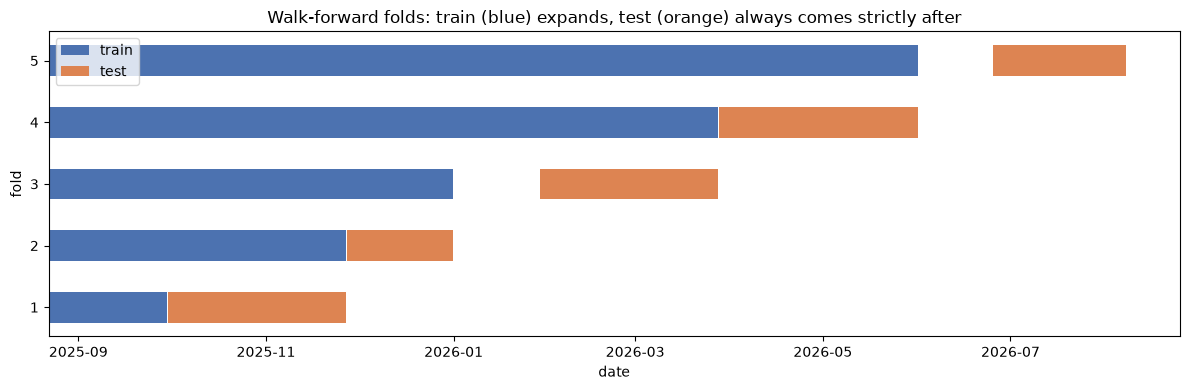

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

for fold, (train_mask, test_mask) in enumerate(day_grouped_splits(df["timestamp_utc"], n_splits=5), start=1):
    train_dates = df.loc[train_mask, "timestamp_utc"]
    test_dates = df.loc[test_mask, "timestamp_utc"]
    ax.barh(fold, (train_dates.max() - train_dates.min()), left=train_dates.min(),
            height=0.5, color="#4C72B0", label="train" if fold == 1 else None)
    ax.barh(fold, (test_dates.max() - test_dates.min()), left=test_dates.min(),
            height=0.5, color="#DD8452", label="test" if fold == 1 else None)

ax.set_yticks(range(1, 6))
ax.set_ylabel("fold")
ax.set_xlabel("date")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title("Walk-forward folds: train (blue) expands, test (orange) always comes strictly after")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "figures" / "3.1-walk-forward-folds.png", dpi=200)
plt.show()

In [5]:
# Confirm the split behaves as claimed before trusting it in evaluate(): every
# fold's test days start strictly after that fold's train days end, and no
# calendar day appears on both sides of any fold. (Also exercised directly
# against day_grouped_splits in tests/test_evaluate.py.)
dates = df["timestamp_utc"]
for fold, (train_mask, test_mask) in enumerate(day_grouped_splits(dates, n_splits=5), start=1):
    train_days = set(dates[train_mask].dt.normalize())
    test_days = set(dates[test_mask].dt.normalize())
    overlap = train_days & test_days
    assert not overlap, f"fold {fold}: {len(overlap)} day(s) split across train and test"
    assert max(train_days) < min(test_days), f"fold {fold}: test does not start strictly after train"
    print(
        f"fold {fold}: train {train_mask.sum():4d} rows "
        f"({dates[train_mask].min().date()} to {dates[train_mask].max().date()}), "
        f"test {test_mask.sum():4d} rows "
        f"({dates[test_mask].min().date()} to {dates[test_mask].max().date()})"
    )

print("\nPASS: every fold is strictly chronological, no day split across train/test.")

fold 1: train  271 rows (2025-08-22 to 2025-09-29), test  265 rows (2025-09-30 to 2025-11-26)
fold 2: train  536 rows (2025-08-22 to 2025-11-26), test  176 rows (2025-11-27 to 2025-12-31)
fold 3: train  712 rows (2025-08-22 to 2025-12-31), test  348 rows (2026-01-28 to 2026-03-27)
fold 4: train 1060 rows (2025-08-22 to 2026-03-27), test  387 rows (2026-03-28 to 2026-05-31)
fold 5: train 1447 rows (2025-08-22 to 2026-05-31), test  529 rows (2026-06-25 to 2026-08-07)

PASS: every fold is strictly chronological, no day split across train/test.


## 4) `evaluate()`: the shared entry point

```python
evaluate(model_factory, data, feature_cols, label_col="label_direction", n_splits=5) -> EvalResult
```

`model_factory` is a zero-argument callable returning a fresh, unfitted model each time - `lambda: lgb.LGBMClassifier(**params)`, or just a class like `MajorityClassifier` (calling a class with no extra `__init__` args is itself a valid zero-arg factory). A factory rather than a fitted instance, and rather than `sklearn.base.clone()`, for two reasons: walk-forward CV needs a genuinely fresh model per fold, and a factory works for *any* model type - a plain callable has no requirement to be an sklearn `BaseEstimator`, unlike `clone()`. That matters the moment a model isn't sklearn-shaped at all, e.g. a FinBERT fine-tune.

`EvalResult` holds:

- **`.folds`** - one `FoldResult` per fold: `.model` (the fitted estimator), `.train_idx`/`.test_idx` (positional row indices into the sorted data), `.y_pred`/`.y_proba`, and `.metrics` (that fold's dict from below).
- **`.metrics_df`** - the same per-fold metrics as a tidy DataFrame.
- **`.aggregate`** - mean and std of every metric across folds.
- **`.models`** - just the fold models, in order, for convenience - e.g. for `feature_importance()`, which reuses them rather than re-fitting (see `stock_predictor/market/evaluate.py`; using it on a real model is for the later modelling notebook, not this one).

Every fold's metrics dict reports:

- **accuracy, precision, recall, f1** - precision/recall matter here specifically because the majority class shifts fold to fold; a single accuracy number can hide a model that's just riding whichever class happened to be more common.
- **auc** - ranking quality, independent of the classification threshold. The positive class is `max(model.classes_)`, which for `label_direction` (-1/1) is `1` ("up").
- **log_loss, brier_score** - accuracy and AUC don't care whether a model's *probabilities* are trustworthy, only whether its ranking or its argmax is right. These do.
- **majority_baseline_accuracy** - always predicting that fold's own training-set majority class, the floor a model has to clear.
- **mcnemar_p_value, significantly_beats_baseline** - accuracy beating the baseline by a few points on 200 rows can be noise. McNemar's test looks only at the rows where the model and the baseline disagree, and asks whether the model is right on *those* significantly more often - a one-sided exact binomial test. `beats_baseline` is the crude version of the same question; `significantly_beats_baseline` is the one to trust.

## 5) Validate the harness before trusting it
The full validation suite - including a positive control that trains on a feature engineered to perfectly determine the label, confirming the harness recognises real skill and not just the *absence* of skill - lives in `tests/test_evaluate.py`. The two cheapest, most illustrative checks are repeated here, run directly against the real feature columns rather than synthetic data:

- A classifier that always predicts the majority class - `evaluate()` should report `accuracy == majority_baseline_accuracy` in every fold. `mcnemar_p_value` comes out `NaN` for every fold too, and that's expected, not a bug: McNemar's test only has something to say about rows where the model and the baseline *disagree*, and `MajorityClassifier` predicts exactly what the baseline predicts, row for row, so there are zero disagreements to test. A real model will disagree with the baseline on at least some rows and get a real p-value - see the `RandomClassifier` check just below, which does.
- A classifier that predicts random probabilities, ignoring the features entirely - AUC should land near 0.5.

In [6]:
from sklearn.base import BaseEstimator, ClassifierMixin


class MajorityClassifier(BaseEstimator, ClassifierMixin):
    """Always predicts the majority class seen in training."""

    def fit(self, X, y):
        values, counts = np.unique(y, return_counts=True)
        self.classes_ = values
        self.majority_ = values[np.argmax(counts)]
        return self

    def predict(self, X):
        return np.full(len(X), self.majority_)

    def predict_proba(self, X):
        proba = np.zeros((len(X), len(self.classes_)))
        proba[:, list(self.classes_).index(self.majority_)] = 1.0
        return proba


class RandomClassifier(BaseEstimator, ClassifierMixin):
    """Predicts random probabilities, ignoring X entirely."""

    def __init__(self, random_state: int = 42):
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        rng = np.random.default_rng(self.random_state)
        p = rng.random(len(X))
        return np.column_stack([1 - p, p])

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[np.argmax(proba, axis=1)]

In [7]:
majority_result = evaluate(MajorityClassifier, df, MARKET_FEATURE_COLS)
majority_metrics = majority_result.metrics_df
print("Majority-classifier check (accuracy must equal majority_baseline_accuracy):")
print(majority_metrics[["fold", "accuracy", "majority_baseline_accuracy", "mcnemar_p_value"]].to_string(index=False))
print(
    "(mcnemar_p_value is NaN in every fold here by construction: MajorityClassifier's "
    "predictions are identical to the baseline's, so there are no disagreements between "
    "them for McNemar's test to compare. Not a bug; see section 5's intro.)"
)

assert np.allclose(majority_metrics["accuracy"], majority_metrics["majority_baseline_accuracy"])
assert majority_metrics["mcnemar_p_value"].isna().all()
print("\nPASS: accuracy matches the baseline exactly, no discordant pairs to test.\n")

random_result = evaluate(RandomClassifier, df, MARKET_FEATURE_COLS)
random_metrics = random_result.metrics_df
print("Random-probability check (AUC should be close to 0.5; mcnemar_p_value is real here, unlike above,")
print("since a random guesser does disagree with the baseline on some rows):")
print(random_metrics[["fold", "auc", "mcnemar_p_value"]].to_string(index=False))

mean_auc = random_metrics["auc"].mean()
assert abs(mean_auc - 0.5) < 0.1, f"random classifier's mean AUC ({mean_auc:.3f}) is too far from 0.5"
print(f"\nPASS: mean AUC across folds is {mean_auc:.3f}, close to the 0.5 a random guesser should get.")

Majority-classifier check (accuracy must equal majority_baseline_accuracy):
 fold  accuracy  majority_baseline_accuracy  mcnemar_p_value
    1  0.694340                    0.694340              NaN
    2  0.198864                    0.198864              NaN
    3  0.390805                    0.390805              NaN
    4  0.571059                    0.571059              NaN
    5  0.391304                    0.391304              NaN
(mcnemar_p_value is NaN in every fold here by construction: MajorityClassifier's predictions are identical to the baseline's, so there are no disagreements between them for McNemar's test to compare. Not a bug; see section 5's intro.)

PASS: accuracy matches the baseline exactly, no discordant pairs to test.



Random-probability check (AUC should be close to 0.5; mcnemar_p_value is real here, unlike above,
since a random guesser does disagree with the baseline on some rows):
 fold      auc  mcnemar_p_value
    1 0.457729     1.000000e+00
    2 0.583992     4.814888e-11
    3 0.458484     5.198522e-03
    4 0.452461     9.985064e-01
    5 0.470699     5.899577e-03

PASS: mean AUC across folds is 0.485, close to the 0.5 a random guesser should get.


## Summary

`stock_predictor.market.evaluate` is the shared walk-forward evaluation path every model in this project should run through:

1. **`evaluate(model_factory, data, feature_cols, ...) -> EvalResult`** - day-grouped, expanding-window, never-shuffled CV. `model_factory` is a zero-argument callable, not a fitted instance or `sklearn.clone()`, so this works for any model type. `EvalResult` carries every fold's model, predictions, train/test indices, and metrics by default, plus the cross-fold aggregate - nothing about a fold has to be re-derived to inspect it later.
2. **Tuning wraps around `evaluate()`**, never inside it - call it repeatedly with different `model_factory` configs, compare `.aggregate`, pick a winner.
3. **`fit_final_model(model_factory, data, feature_cols)`** - a separate, final step: refit once on every row, no split, for the artifact that ships.
4. **The shipped model is never scored.** The walk-forward fold metrics from step 1 are the only real performance numbers this project reports, on this model or any other.

There is no held-out block anywhere in this harness, deliberately - see the intro for why.

The harness was validated before being trusted, both here (majority-only and random-probability checks against the real features) and more thoroughly in `tests/test_evaluate.py` (24 tests, including a positive control that confirms the harness recognises genuine signal, not just its absence, and coverage that every fold's model/predictions/indices are the genuine article rather than shared or stale).